**Sentiment Analysis**

Imports for Sentiment Analysis

In [1]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer # for VADER (for sentiment analysis) 
import nltk # for NLP tools (tokenization, lexicons) 
import pandas as pd # for handling df (dataframes) 
import re # for regular expression
import numpy as np # for handling numerical operations
import spacy # spaCy for NLP & parsing
from nltk.tokenize import sent_tokenize, word_tokenize # sentence and word tokenizors

nltk.download('punkt') # download tokenizor models
nltk.download('vader_lexicon') # download VADER lexicon for sentiment scoring

# initialize analyzer
analyzer = SentimentIntensityAnalyzer() # create VADER sentiment analyzer object
nlp = spacy.load("en_core_web_sm") # load small spaCy English model

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Overall Sentiment Analysis

In [2]:
# Load preprocessed dataset
combined_df = pd.read_csv('combined_reviews.csv')

# Define a safe function for handling sentiment scoring
def get_vader_scores(text):
    if pd.isna(text):  # if review is missing
        return pd.Series({'neg': np.nan, 'neu': np.nan, 'pos': np.nan, 'compound': np.nan})
    else:
        scores = analyzer.polarity_scores(str(text))
        return pd.Series(scores)

# Apply to cleaned_review_text column
combined_df[['neg', 'neu', 'pos', 'compound']] = combined_df['cleaned_review_text'].apply(get_vader_scores)

# Define sentiment label function based on compound score
def get_sentiment_label(score):
    if pd.isna(score):
        return np.nan
    elif score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply to get sentiment_label
combined_df['sentiment_label'] = combined_df['compound'].apply(get_sentiment_label)


Implementing Aspect Based Sentiment Analysis (ABSA)

In [3]:

# possible words in each rating aspect
aspects = {
    "seat": ["seat", "seating", "seatbelt", "legroom"],
    "staff": ["staff", "crew", "attendant", "service"],
    "food": ["food", "meal", "breakfast", "lunch", "dinner", "snack"],
    "entertainment": ["entertainment", "screen", "movies", "ife"],
    "ground": ["ground", "checkin", "airport", "baggage", "luggage"],
    "wifi": ["wifi", "internet", "connectivity"],
    "value": ["value", "price", "worth", "money"]
}

def absa_spacy(review):
    # prepare result dict with prefixed column names (no overwrite)
    results = {f"absa_{a}": 0.0 for a in aspects.keys()}

    if pd.isna(review):
        return pd.Series(results)

    doc = nlp(str(review))  # parse review with spaCy (keeps sentence structure)

    # collect candidate phrases (adjectives / modifiers) for each aspect
    aspect_phrases = {a: [] for a in aspects.keys()}

    # iterate tokens to find aspect mentions and related modifiers
    for token in doc:
        token_lemma = token.lemma_.lower()
        for aspect, keywords in aspects.items():
            if token_lemma in keywords:
                # check adjectival modifiers and adjectival complements
                for child in token.children:
                    if child.dep_ in ("amod", "acomp", "advmod"):
                        aspect_phrases[aspect].append(child.text)
                # check for preceding adjective (e.g., "comfortable seat")
                prev = token.nbor(-1) if token.i > 0 else None
                if prev is not None and prev.pos_ == "ADJ":
                    aspect_phrases[aspect].append(prev.text)
                # also check for adjective in the same sentence (fallback)
                for tok in token.sent:
                    if tok.pos_ == "ADJ":
                        # keep short phrases only to reduce noise
                        aspect_phrases[aspect].append(tok.text)

    # compute VADER scores for collected phrases (use analyzer)
    for aspect in aspects.keys():
        phrases = [p for p in aspect_phrases[aspect] if isinstance(p, str) and p.strip() != ""]
        if len(phrases) == 0:
            results[f"absa_{aspect}"] = 0.0
        else:
            scores = [analyzer.polarity_scores(p)["compound"] for p in phrases]  # <--- use analyzer here
            results[f"absa_{aspect}"] = float(sum(scores) / len(scores))

    return pd.Series(results)

combined_df[[f"absa_{a}" for a in aspects.keys()]] = combined_df["review_text"].apply(absa_spacy)

combined_df.to_csv('combined_with_sentiment.csv', index=False, na_rep='NaN')


C:\Users\JulianYip\AppData\Local\Temp\ipykernel_2448\3476452265.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.values, y=[l.replace('absa_', '').title() for l in avg_scores.index], palette=colors)


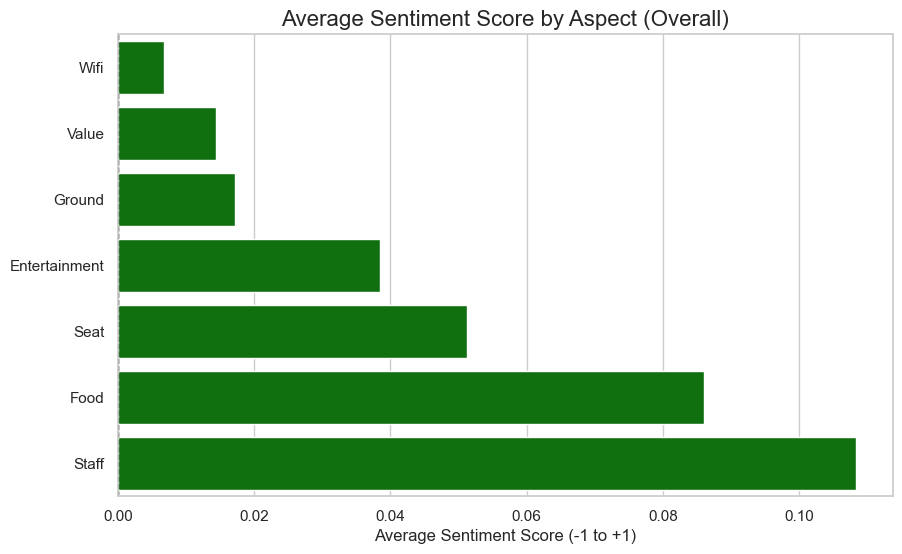

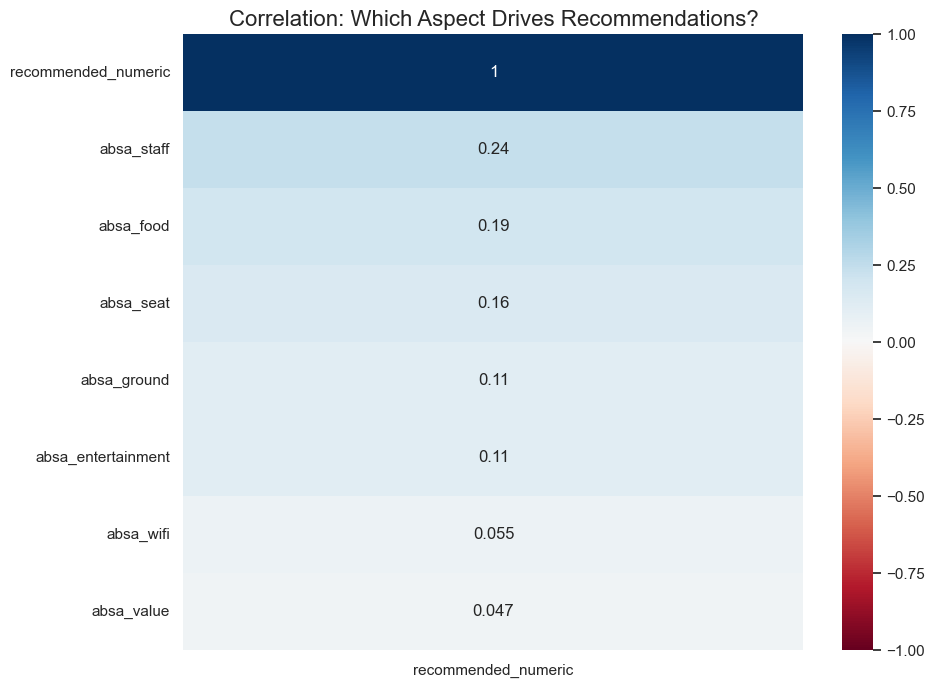

C:\Users\JulianYip\AppData\Local\Temp\ipykernel_2448\3476452265.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mentions_only, y='aspect',


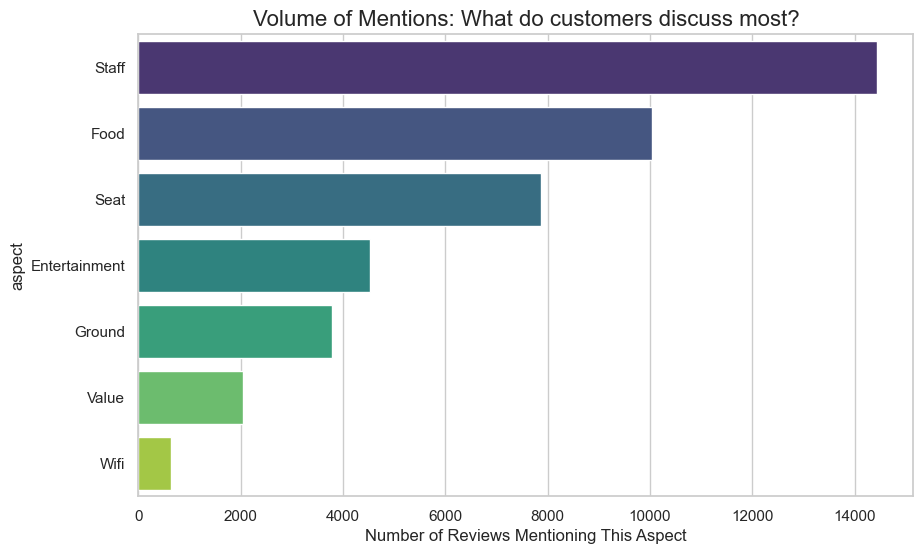

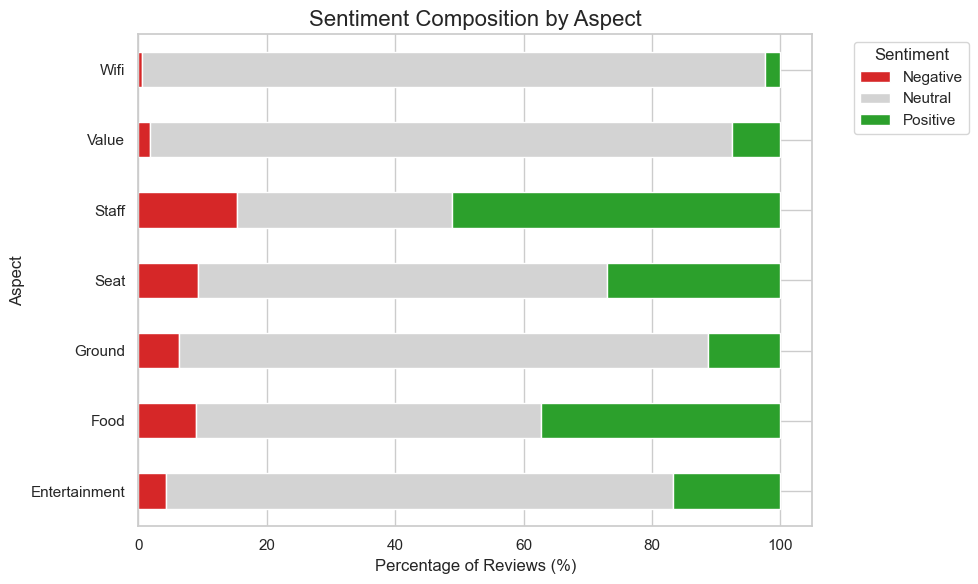

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('combined_with_sentiment.csv') 

absa_cols = ['absa_seat', 'absa_staff', 'absa_food', 'absa_entertainment', 
             'absa_ground', 'absa_wifi', 'absa_value']

# Clean up column names for nicer labels
clean_labels = [col.replace('absa_', '').title() for col in absa_cols]

# Set the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: AVERAGE SENTIMENT (The "Pain Points")
# ==========================================
plt.figure(figsize=(10, 6))
avg_scores = df[absa_cols].mean().sort_values() 

# Create bar chart
colors = ['red' if x < 0 else 'green' for x in avg_scores]
sns.barplot(x=avg_scores.values, y=[l.replace('absa_', '').title() for l in avg_scores.index], palette=colors)

plt.title('Average Sentiment Score by Aspect (Overall)', fontsize=16)
plt.xlabel('Average Sentiment Score (-1 to +1)')
plt.axvline(0, color='black', linestyle='--', linewidth=1) 
plt.show()

# ==========================================
# PLOT 2: DISTRIBUTION BOXPLOTS (Fixed: No Outliers)
# ==========================================
# plt.figure(figsize=(12, 6))

# FIX: Added 'showfliers=False' to hide the black dots
#sns.boxplot(data=df[absa_cols], orient='h', palette="coolwarm", showfliers=False)

# plt.yticks(range(len(clean_labels)), clean_labels) 
# plt.title('Distribution of Sentiment Scores per Aspect (Outliers Hidden)', fontsize=16)
# plt.xlabel('Sentiment Score')
# plt.show()

# ==========================================
# PLOT 3: CORRELATION HEATMAP (The "Drivers")
# ==========================================
# Convert 'recommended' to numbers if needed
df['recommended_numeric'] = df['recommended'].apply(lambda x: 1 if str(x).lower() in ['yes', 'true', '1', 'recommended'] else 0)

corr_data = df[absa_cols + ['recommended_numeric']]
correlation = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation[['recommended_numeric']].sort_values(by='recommended_numeric', ascending=False), 
            annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Correlation: Which Aspect Drives Recommendations?', fontsize=16)
plt.show()

# ==========================================
# PLOT 4: MENTION FREQUENCY (The "Volume" Chart)
# ==========================================
# Helper function to categorize scores
def categorize_sentiment(score):
    if score > 0.01: return 'Positive'
    if score < -0.01: return 'Negative'
    return 'Neutral'

# Prepare data for plotting
plot_df = pd.DataFrame()
for col in absa_cols:
    temp = df[[col]].copy()
    temp.columns = ['score']
    temp['aspect'] = col.replace('absa_', '').title()
    temp['sentiment_category'] = temp['score'].apply(categorize_sentiment)
    plot_df = pd.concat([plot_df, temp])

plt.figure(figsize=(10, 6))
# Filter out 'Neutral' (0.0) to see only active discussions
mentions_only = plot_df[plot_df['sentiment_category'] != 'Neutral']

sns.countplot(data=mentions_only, y='aspect', 
              order=mentions_only['aspect'].value_counts().index, 
              palette='viridis')

plt.title('Volume of Mentions: What do customers discuss most?', fontsize=16)
plt.xlabel('Number of Reviews Mentioning This Aspect')
plt.show()

# ==========================================
# PLOT 5: SENTIMENT COMPOSITION (The "Stacked" Chart)
# ==========================================
# Calculate percentages
sentiment_counts = (plot_df.groupby(['aspect', 'sentiment_category'])
                    .size()
                    .unstack(fill_value=0))

# Convert to percentage
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# Reorder columns for logical flow
sentiment_pct = sentiment_pct[['Negative', 'Neutral', 'Positive']]

# Plot
sentiment_pct.plot(kind='barh', stacked=True, color=['#d62728', '#d3d3d3', '#2ca02c'], figsize=(10, 6))

plt.title('Sentiment Composition by Aspect', fontsize=16)
plt.xlabel('Percentage of Reviews (%)')
plt.ylabel('Aspect')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()